# EDA IMDB 

## 1.Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
from src.paths import DATA_RAW_IMDB


## 2.Exploration par dataset


Exploration des 5 fichiers IMDB retenus. Pour chaque dataset : structure, valeurs manquantes, observations et décisions de preprocessing.

### 2.1 name.basics (people)


Contient les informations sur les personnes (acteurs, réalisateurs, etc.)  
**15 182 692 lignes — 6 colonnes**

| Colonne | % NaN | Décision |
|---------|-------|----------|
| nconst | 0% | Conserver (clé de jointure) |
| primaryName | 0.05% | Conserver |
| birthYear | 95.6% | **Supprimer** |
| deathYear | 98.3% | **Supprimer** |
| primaryProfession | 20% | Conserver |
| knownForTitles | 11.9% | Conserver |

Afin de gagner du temps je crée une fonction qui inclus Head/shape/et le nombre de NA 

In [6]:
people = pd.read_csv(DATA_RAW_IMDB / "name.basics.tsv", sep='\t',na_values='\\N')

def fast_review(dfs):
    for df in dfs:
        display(df.head())
        print('Shape:', df.shape)
        print(df.isna().mean() * 100)

fast_review([people])

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899.0,1987.0,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924.0,2014.0,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0045891"
2,nm0000003,Brigitte Bardot,1934.0,2025.0,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949.0,1982.0,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918.0,2007.0,"writer,director,actor","tt0050986,tt0069467,tt0050976,tt0083922"


Shape: (15225343, 6)
nconst                0.000000
primaryName           0.000519
birthYear            95.598437
deathYear            98.311276
primaryProfession    20.094634
knownForTitles       11.919679
dtype: float64


### 2.2 title.basics (titre)

Contient les informations de base sur les titres (films, séries, etc.)  
**12 388 768 lignes — 9 colonnes**

| Colonne | % NaN | Décision |
|---------|-------|----------|
| tconst | 0% | Conserver (jointure) |
| titleType | 0% | Conserver — filtre sur 'movie' |
| primaryTitle | 0.02% | Conserver |
| originalTitle | 0.02% | **Supprimer** |
| isAdult | 0% | **Supprimer** |
| startYear | 11.8% | Conserver |
| endYear | 98.8% | **Supprimer** |
| runtimeMinutes | 64% | Conserver |
| genres | 4.3% | Conserver |


In [ ]:

titre = pd.read_csv(DATA_RAW_IMDB / "title.basics.tsv", sep='\t' ,na_values='\\N', low_memory=False)


fast_review([titre])




,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short


Shape: (12420966, 9)
tconst             0.000000
titleType          0.000000
primaryTitle       0.000201
originalTitle      0.000201
isAdult            0.000000
startYear         11.747991
endYear           98.750363
runtimeMinutes    64.064309
genres             4.306799
dtype: float64


### 2.3 title.crew (Crew)

Contient les réalisateurs et scénaristes par titre.  
**12 388 768 lignes — 3 colonnes**

| Colonne | % NaN | Observation |
|---------|-------|-------------|
| tconst | 0% | jointure |
| directors | 44% | NaN élevé |
| writers | 49% | NaN élevé |

À décider : supprimer les colonnes directors/writers (44-49% NaN) ou supprimer entièrement title.crew au profit de title.principals qui couvre les mêmes infos avec 0% NaN.

In [8]:
Crews = pd.read_csv(DATA_RAW_IMDB / "title.crew.tsv", sep='\t',na_values='\\N')

fast_review([Crews])


,tconst,directors,writers
0,tt0000001,nm0005690,NaN
1,tt0000002,nm0721526,NaN
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,NaN
4,tt0000005,nm0005690,NaN


Shape: (12755296, 3)
tconst        0.000000
directors    44.388935
writers      49.378423
dtype: float64


### 2.4 title.principals (Principal)

Table de liaison entre titres et personnes. Contient tous les rôles (acteur, réalisateur, producteur, etc.)  
**98 579 770 lignes — 3 colonnes**

| Colonne | % NaN | Décision |
|---------|-------|----------|
| tconst | 0% | Conserver (jointure) |
| nconst | 0% | Conserver (jointure) |
| category | 0% | Conserver |

0% de NaN sur 98M de lignes. Remplace title.crew.

In [9]:
Principal = pd.read_csv(DATA_RAW_IMDB / "title.principals.tsv", sep='\t', na_values='\\N', usecols=['tconst', 'nconst', 'category'])


fast_review([Principal])


,tconst,nconst,category
0,tt0000001,nm1588970,self
1,tt0000001,nm0005690,director
2,tt0000001,nm0005690,producer
3,tt0000001,nm0374658,cinematographer
4,tt0000002,nm0721526,director


Shape: (98825098, 3)
tconst      0.0
nconst      0.0
category    0.0
dtype: float64


### 2.5 title.ratings (Ratings)

Contient les notes moyennes et le nombre de votes par titre.  
**1 652 901 lignes — 3 colonnes**

| Colonne | % NaN | Décision |
|---------|-------|----------|
| tconst | 0% | Conserver (jointure) |
| averageRating | 0% | Conserver |
| numVotes | 0% | Conserver |

Variable cible. 0% de NaN.

In [10]:
Ratings = pd.read_csv(DATA_RAW_IMDB / "title.ratings.tsv", sep='\t',na_values='\\N')

fast_review([Ratings])


,tconst,averageRating,numVotes
0,tt0000001,5.7,2201
1,tt0000002,5.5,312
2,tt0000003,6.4,2314
3,tt0000004,5.1,197
4,tt0000005,6.2,3039


Shape: (1658155, 3)
tconst           0.0
averageRating    0.0
numVotes         0.0
dtype: float64


## 3.Visualisation

Avant tout je vais filtrer les films uniquement

In [53]:
titre_movie = titre[titre['titleType'] == 'movie']
df_films = titre_movie.merge(Ratings, on='tconst',how='left')

In [54]:
print()
print(df_films.shape)
df_films['numVotes'].isna().sum()


(742654, 11)


np.int64(400693)

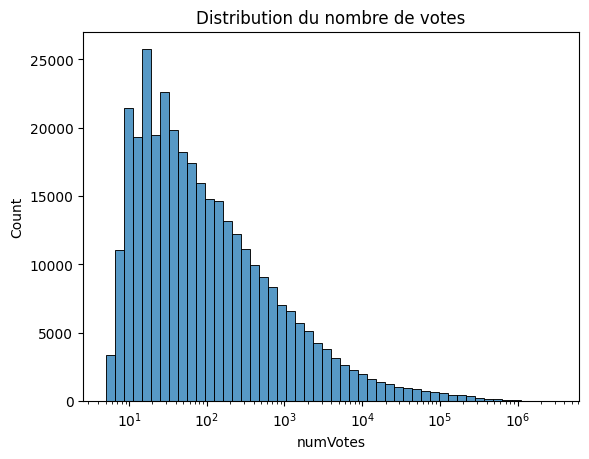

In [55]:

sns.histplot(df_films['numVotes'], log_scale=True, bins=50)
plt.title('Distribution du nombre de votes');


On peut constater que la répartition est extrêmement asymétrique, il faudra trouver une solution de preprocessing

Explorons les genres, d'abord je split et transforme en liste

In [56]:
titre_genre = titre_movie['genres'].str.split(',')

titre_genre.head()

genre_counts = titre_genre.explode().value_counts()

Visualisons le top des genres

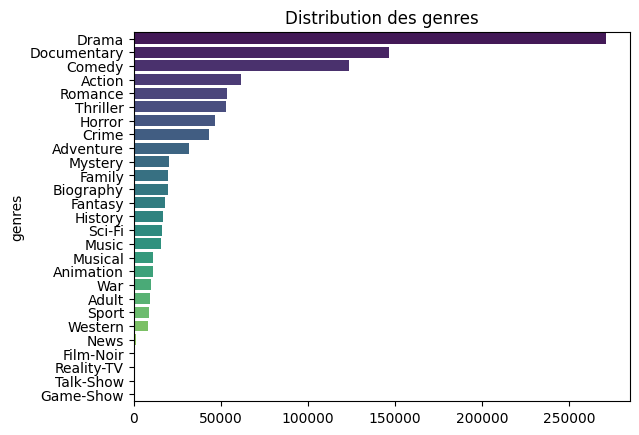

In [62]:
sns.barplot(y=genre_counts.index, x=genre_counts.values, hue=genre_counts.index, palette='viridis')
plt.title('Distribution des genres')
plt.show()

On constate quelque genre residuels(talk-show, news etc...), a surveiller en preproc si besoin 